#  Deteksi Dini Risiko Diabetes Menggunakan Algoritma Random Forest dan XGBoost Berbasis Website dengan Rekomendasi AI



> **Metodologi:** CRISP-DM *(Cross Industry Standard Process for Data Mining)*  
> **Algoritma    :** Random Forest & XGBoost  
> **Dataset      :** diabetes_dataset.csv (100.000 baris × 31 kolom)  
> **Fitur Input  :** 8 Fitur Terpilih Berbasis Feature Importance

---

##  Alur CRISP-DM

```
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment (Export Model)
```


---
##  FASE 1 — Business Understanding

Fase pertama CRISP-DM adalah memahami tujuan bisnis dan menerjemahkannya ke dalam permasalahan data mining.


### 1.1 Latar Belakang

Diabetes mellitus merupakan salah satu penyakit kronis yang prevalensinya terus meningkat secara global. Deteksi dini sangat krusial untuk mencegah komplikasi serius. Sistem berbasis *machine learning* dapat membantu masyarakat umum dalam mendeteksi risiko diabetes secara cepat dan akurat.

Pada penelitian ini, dipilih **8 fitur utama** yang paling representatif dan mudah diperoleh oleh pengguna awam, berdasarkan:
1. Relevansi medis (literatur kesehatan)
2. Feature importance dari algoritma Random Forest & XGBoost
3. Kemudahan pengisian oleh pengguna di aplikasi web


### 1.2 Tujuan Penelitian

1. Membangun model klasifikasi untuk mendeteksi dini risiko diabetes menggunakan 8 fitur terpilih.
2. Membandingkan performa algoritma **Random Forest** dan **XGBoost**.
3. Mengintegrasikan model ke dalam aplikasi web dengan fitur rekomendasi berbasis AI.


### 1.3 Pemilihan 8 Fitur Input

Dari 30 kolom fitur yang tersedia pada dataset, dipilih **8 fitur** berikut berdasarkan relevansi medis dan kemudahan pengisian oleh pengguna:

| No | Nama Kolom | Deskripsi | Alasan Dipilih |
|---|---|---|---|
| 1 | `age` | Usia pasien (tahun) | Faktor risiko utama diabetes |
| 2 | `bmi` | Body Mass Index | Indikator obesitas, korelasi kuat |
| 3 | `hba1c` | HbA1c Level (%) | Indikator gula darah jangka panjang |
| 4 | `glucose_fasting` | Gula darah puasa (mg/dL) | Indikator langsung diabetes |
| 5 | `hypertension_history` | Riwayat hipertensi (0/1) | Komorbiditas kuat dengan diabetes |
| 6 | `family_history_diabetes` | Riwayat keluarga diabetes (0/1) | Faktor genetik dominan |
| 7 | `smoking_status` | Status merokok | Faktor gaya hidup |
| 8 | `physical_activity_minutes_per_week` | Aktivitas fisik (menit/minggu) | Faktor gaya hidup |


---
## FASE 2 — Data Understanding

Fase ini bertujuan memahami struktur, kualitas, dan karakteristik dataset yang akan digunakan.


### 2.1 Import Library

Mengimport seluruh library yang dibutuhkan dalam proses analisis data, pemodelan, evaluasi, dan visualisasi.


In [1]:
# ── Import Library Utama ──────────────────────────────────────────────────────
# pandas  : manipulasi dan analisis data tabular (DataFrame)
# numpy   : operasi numerik dan array
# matplotlib / seaborn : visualisasi grafik
# warnings : menyembunyikan pesan warning agar output lebih bersih
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" Library dasar berhasil diimport")


 Library dasar berhasil diimport


In [2]:
# ── Import Library Machine Learning ──────────────────────────────────────────
# train_test_split      : membagi data menjadi train & test
# cross_val_score       : evaluasi model dengan k-fold cross validation
# StratifiedKFold       : pembagian fold yang menjaga proporsi kelas
# LabelEncoder          : mengubah data kategorikal (teks) menjadi angka
# StandardScaler        : standarisasi fitur agar skala seragam
# RandomForestClassifier: algoritma Random Forest untuk klasifikasi
# XGBClassifier         : algoritma XGBoost untuk klasifikasi
# accuracy_score dll    : metrik evaluasi model
# joblib                : menyimpan/memuat model ke file .pkl
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
import joblib

print(" Library Machine Learning berhasil diimport")


 Library Machine Learning berhasil diimport


In [3]:
# ── Konfigurasi Style Visualisasi ─────────────────────────────────────────────
# Mengatur ukuran default grafik dan tema warna visualisasi
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')

print(" Konfigurasi visualisasi berhasil diset")


 Konfigurasi visualisasi berhasil diset


### 2.2 Load Dataset

Memuat dataset diabetes ke dalam DataFrame pandas untuk proses eksplorasi awal.


In [4]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
# pd.read_csv() membaca file CSV menjadi DataFrame pandas
# df.shape mengembalikan (jumlah_baris, jumlah_kolom)
df = pd.read_csv('diabetes_dataset.csv')
print(f" Dataset berhasil dimuat")
print(f"   Jumlah baris  : {df.shape[0]:,}")
print(f"   Jumlah kolom  : {df.shape[1]}")
print(f"\n Daftar semua kolom:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")


 Dataset berhasil dimuat
   Jumlah baris  : 100,000
   Jumlah kolom  : 31

 Daftar semua kolom:
    1. age
    2. gender
    3. ethnicity
    4. education_level
    5. income_level
    6. employment_status
    7. smoking_status
    8. alcohol_consumption_per_week
    9. physical_activity_minutes_per_week
   10. diet_score
   11. sleep_hours_per_day
   12. screen_time_hours_per_day
   13. family_history_diabetes
   14. hypertension_history
   15. cardiovascular_history
   16. bmi
   17. waist_to_hip_ratio
   18. systolic_bp
   19. diastolic_bp
   20. heart_rate
   21. cholesterol_total
   22. hdl_cholesterol
   23. ldl_cholesterol
   24. triglycerides
   25. glucose_fasting
   26. glucose_postprandial
   27. insulin_level
   28. hba1c
   29. diabetes_risk_score
   30. diabetes_stage
   31. diagnosed_diabetes


### 2.3 Tampilan Awal Dataset

Menampilkan 5 baris pertama dataset untuk mendapat gambaran awal tentang isi data.


In [5]:
# ── Tampilan 5 Baris Pertama ──────────────────────────────────────────────────
# df.head() secara default menampilkan 5 baris pertama dataset
# Berguna untuk melihat apakah data sudah terbaca dengan benar
print(" 5 Baris Pertama Dataset:")
df.head()


 5 Baris Pertama Dataset:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


### 2.4 Informasi Struktur Dataset


In [6]:
# ── Info Tipe Data dan Non-Null Count ─────────────────────────────────────────
# df.info() menampilkan: nama kolom, jumlah non-null, dan tipe data
# Berguna untuk mengetahui kolom mana yang perlu ditangani (null / tipe salah)
print(" Informasi Kolom dan Tipe Data:")
df.info()


 Informasi Kolom dan Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64


### 2.5 Pengecekan Nilai Duplikat

Baris duplikat dapat menyebabkan bias pada model sehingga perlu diidentifikasi.


In [7]:
# ── Cek Baris Duplikat ────────────────────────────────────────────────────────
# df.duplicated().sum() menghitung jumlah baris yang persis sama dengan baris lain
jumlah_duplikat = df.duplicated().sum()
print(f" Jumlah baris duplikat : {jumlah_duplikat}")
if jumlah_duplikat > 0:
    print("  Terdapat duplikat — akan dihapus pada fase Data Preparation")
else:
    print(" Tidak ada baris duplikat dalam dataset")


 Jumlah baris duplikat : 0
 Tidak ada baris duplikat dalam dataset


### 2.6 Pengecekan Missing Values

Nilai yang hilang dapat menurunkan kualitas model.


In [8]:
# ── Cek Missing Values per Kolom ──────────────────────────────────────────────
# df.isnull().sum() menghitung jumlah nilai kosong (NaN) pada setiap kolom
# Kemudian dikalkulasi persentasenya terhadap total baris
null_counts  = df.isnull().sum()
null_percent = (null_counts / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Jumlah Null'   : null_counts,
    'Persentase (%)': null_percent
})

print(" Ringkasan Missing Values per Kolom:")
if null_summary['Jumlah Null'].sum() > 0:
    print(null_summary[null_summary['Jumlah Null'] > 0])
else:
    print(" Tidak ada missing values dalam dataset")


 Ringkasan Missing Values per Kolom:
 Tidak ada missing values dalam dataset


### 2.7 Distribusi Variabel Target

Menampilkan distribusi kelas target `diagnosed_diabetes` untuk mengetahui apakah dataset seimbang atau tidak.


 Distribusi Variabel Target 'diagnosed_diabetes':
   1 (Positif Diabetes) : 59,998 (60.00%)
   0 (Negatif Diabetes) : 40,002 (40.00%)


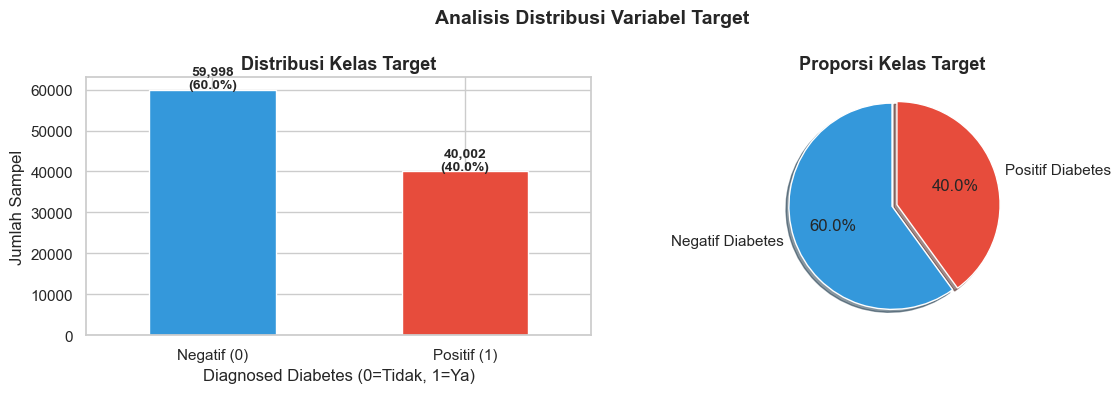

 Visualisasi distribusi target ditampilkan


In [9]:
# ── Distribusi Variabel Target ────────────────────────────────────────────────
# Variabel target: diagnosed_diabetes (0 = Tidak Diabetes, 1 = Diabetes)
# value_counts() menghitung frekuensi setiap nilai unik
# normalize=True mengubah frekuensi menjadi proporsi (persentase)
target_counts = df['diagnosed_diabetes'].value_counts()
target_pct    = df['diagnosed_diabetes'].value_counts(normalize=True) * 100

print(" Distribusi Variabel Target 'diagnosed_diabetes':")
for label, count, pct in zip(target_counts.index, target_counts.values, target_pct.values):
    status = 'Positif Diabetes' if label == 1 else 'Negatif Diabetes'
    print(f"   {label} ({status}) : {count:,} ({pct:.2f}%)")

# ── Visualisasi Distribusi Target (Bar Chart) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#3498db', '#e74c3c']
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diagnosed Diabetes (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xticklabels(['Negatif (0)', 'Positif (1)'], rotation=0)
for i, (val, pct) in enumerate(zip(target_counts, target_pct)):
    axes[0].text(i, val + 300, f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(
    target_counts,
    labels=['Negatif Diabetes', 'Positif Diabetes'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.05),
    shadow=True
)
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Distribusi Variabel Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi distribusi target ditampilkan")


### 2.8 Eksplorasi 8 Fitur Terpilih

Menganalisis distribusi 8 fitur yang akan digunakan sebagai input model.


In [10]:
# ── Definisi 8 Fitur Terpilih ─────────────────────────────────────────────────
# Ini adalah kolom-kolom yang akan digunakan sebagai input model dan input user di web
# Dipilih berdasarkan: relevansi medis + kemudahan pengisian pengguna
SELECTED_FEATURES = [
    'age',                                  # Usia
    'bmi',                                  # Body Mass Index
    'hba1c',                                # HbA1c (gula darah jangka panjang)
    'glucose_fasting',                      # Gula darah puasa
    'hypertension_history',                 # Riwayat hipertensi
    'family_history_diabetes',              # Riwayat keluarga diabetes
    'smoking_status',                       # Status merokok
    'physical_activity_minutes_per_week'    # Aktivitas fisik per minggu
]

TARGET = 'diagnosed_diabetes'

print(" 8 Fitur terpilih:")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f"   {i}. {f}")


 8 Fitur terpilih:
   1. age
   2. bmi
   3. hba1c
   4. glucose_fasting
   5. hypertension_history
   6. family_history_diabetes
   7. smoking_status
   8. physical_activity_minutes_per_week


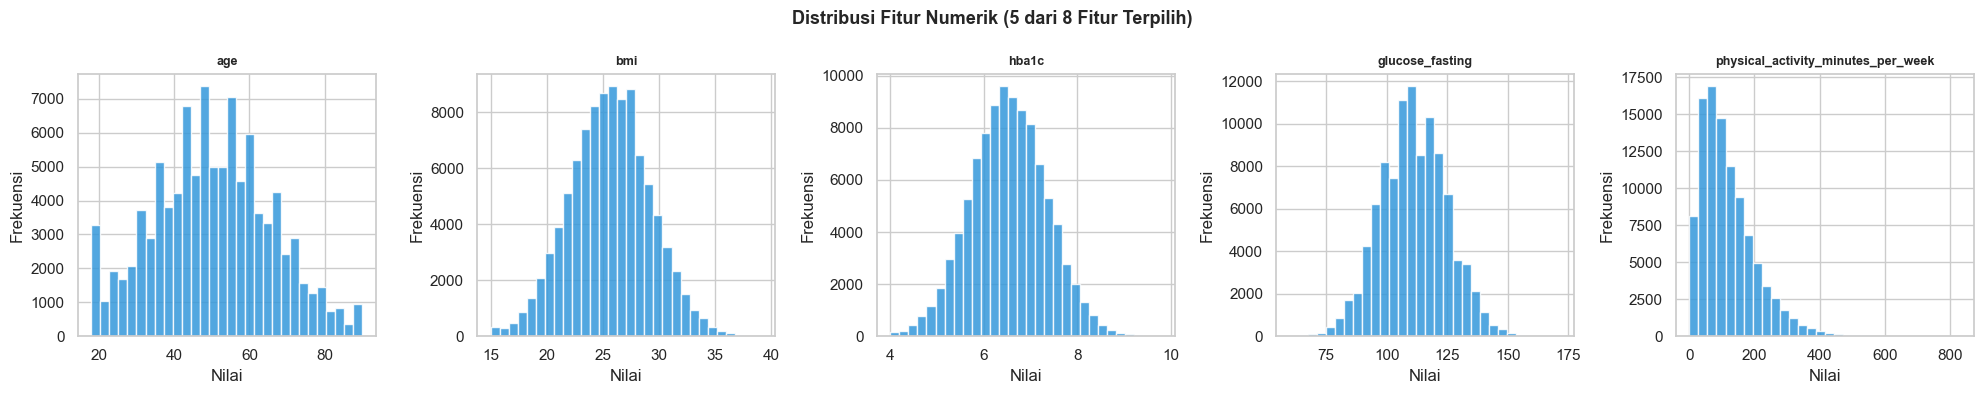

 Histogram fitur numerik ditampilkan


In [11]:
# ── Distribusi 8 Fitur Numerik (Histogram) ────────────────────────────────────
# Histogram menampilkan sebaran nilai dari setiap fitur numerik
# bins=30 artinya data dibagi menjadi 30 interval (batang)
# Berguna untuk melihat apakah data terdistribusi normal atau miring (skewed)
num_features = ['age', 'bmi', 'hba1c', 'glucose_fasting', 'physical_activity_minutes_per_week']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Frekuensi')
    axes[i].set_xlabel('Nilai')

plt.suptitle('Distribusi Fitur Numerik (5 dari 8 Fitur Terpilih)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_histogram_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Histogram fitur numerik ditampilkan")


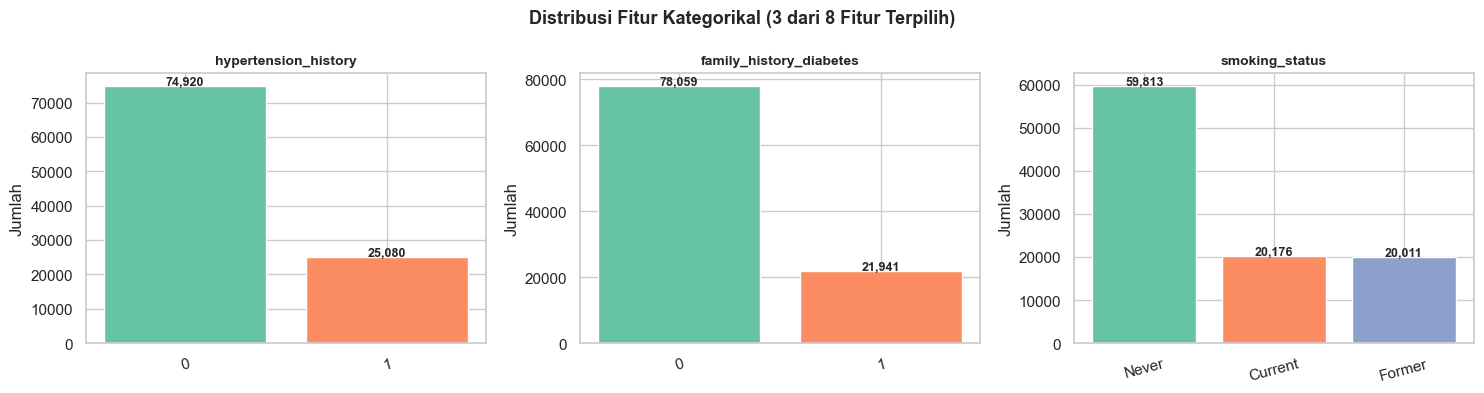

 Visualisasi fitur kategorikal ditampilkan


In [12]:
# ── Distribusi Fitur Kategorikal ──────────────────────────────────────────────
# Fitur kategorikal (teks) divisualisasikan dengan bar chart
# value_counts() menghitung frekuensi setiap kategori
cat_features = ['hypertension_history', 'family_history_diabetes', 'smoking_status']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_cat = sns.color_palette('Set2', 5)

for i, col in enumerate(cat_features):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=colors_cat[:len(counts)], edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=15)
    for j, val in enumerate(counts.values):
        axes[i].text(j, val + 200, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Distribusi Fitur Kategorikal (3 dari 8 Fitur Terpilih)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_kategorikal_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi fitur kategorikal ditampilkan")


### 2.9 Analisis Korelasi 8 Fitur Terhadap Target

Menganalisis hubungan antara 8 fitur terpilih dengan variabel target menggunakan heatmap korelasi.


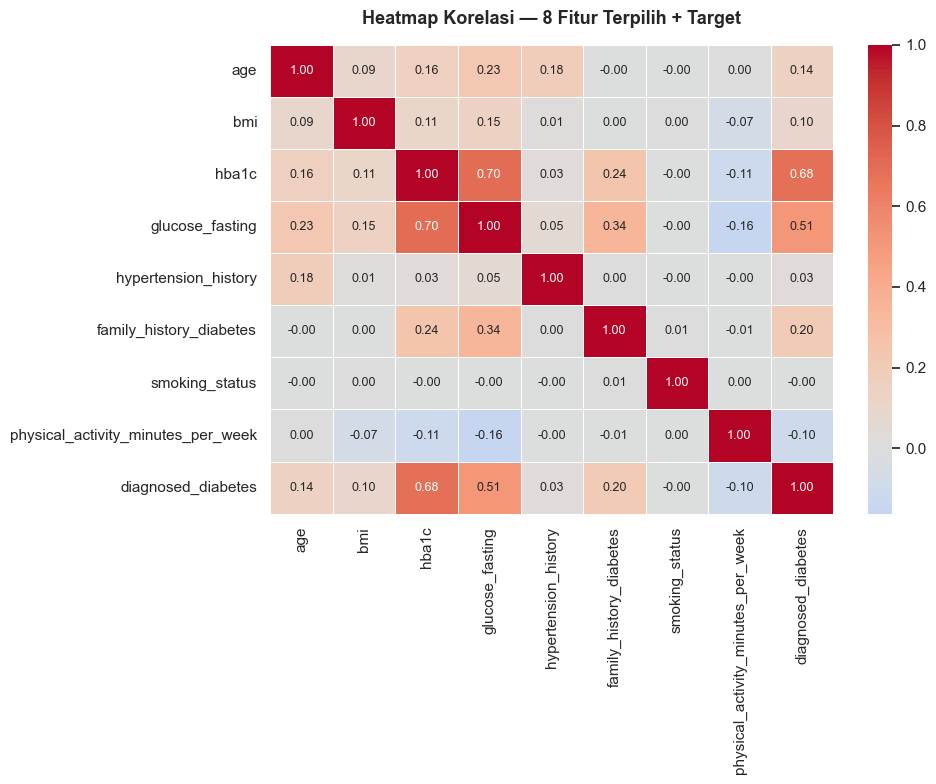

 Heatmap korelasi ditampilkan


In [13]:
# ── Heatmap Korelasi 8 Fitur + Target ────────────────────────────────────────
# corr() menghitung korelasi Pearson antar kolom numerik
# Nilai mendekati 1 atau -1 = korelasi kuat, mendekati 0 = tidak berkorelasi
# Semua kolom bertipe object (teks) harus di-encode dulu ke angka sebelum corr()
# karena fungsi corr() hanya bisa bekerja pada kolom numerik

df_corr = df[SELECTED_FEATURES + [TARGET]].copy()
# Encode semua kolom bertipe object secara otomatis
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

corr_matrix = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Heatmap Korelasi — 8 Fitur Terpilih + Target', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_korelasi_8fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap korelasi ditampilkan")


---
##  FASE 3 — Data Preparation

Fase ini mencakup seluruh proses pembersihan dan transformasi data agar siap digunakan dalam pemodelan.


### 3.1 Seleksi 8 Fitur + Target


In [14]:
# ── Seleksi Kolom yang Digunakan ──────────────────────────────────────────────
# Dari 31 kolom, kita hanya ambil 8 fitur terpilih + 1 kolom target
# Ini menyederhanakan model agar fokus pada fitur yang paling relevan
df_model = df[SELECTED_FEATURES + [TARGET]].copy()

print(f" Dataset setelah seleksi fitur:")
print(f"   Jumlah baris  : {df_model.shape[0]:,}")
print(f"   Jumlah kolom  : {df_model.shape[1]} (8 fitur + 1 target)")
print(f"\n Contoh data:")
df_model.head()


 Dataset setelah seleksi fitur:
   Jumlah baris  : 100,000
   Jumlah kolom  : 9 (8 fitur + 1 target)

 Contoh data:


,age,bmi,hba1c,glucose_fasting,hypertension_history,family_history_diabetes,smoking_status,physical_activity_minutes_per_week,diagnosed_diabetes
0,58,30.5,8.18,136,0,0,Never,215,1
1,48,23.1,5.63,93,0,0,Former,143,0
2,60,22.2,7.51,118,0,1,Never,57,1
3,74,26.8,9.03,139,0,0,Never,49,1
4,46,21.2,7.20,137,0,0,Never,109,1


### 3.2 Penghapusan Baris Duplikat


In [15]:
# ── Hapus Baris Duplikat ──────────────────────────────────────────────────────
# drop_duplicates() menghapus baris yang identik persis dengan baris lain
# inplace=True langsung mengubah DataFrame tanpa perlu membuat salinan baru
before = len(df_model)
df_model.drop_duplicates(inplace=True)
after  = len(df_model)
print(f"  Baris duplikat dihapus : {before - after:,}")
print(f" Jumlah data setelah pembersihan : {after:,}")


  Baris duplikat dihapus : 1
 Jumlah data setelah pembersihan : 99,999


### 3.3 Penanganan Missing Values


In [16]:
# ── Imputasi Missing Values ───────────────────────────────────────────────────
# Strategi imputasi:
#   - Kolom numerik  → diisi dengan MEDIAN (robust terhadap outlier)
#   - Kolom kategori → diisi dengan MODUS (nilai yang paling sering muncul)
# fillna() mengisi nilai NaN dengan nilai yang kita tentukan
num_cols_sel = df_model.select_dtypes(include=[np.number]).columns
cat_cols_sel = df_model.select_dtypes(include='object').columns

for col in num_cols_sel:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)
        print(f"    {col} → diisi dengan median")

for col in cat_cols_sel:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].mode()[0], inplace=True)
        print(f"    {col} → diisi dengan modus")

print(f" Total null tersisa : {df_model.isnull().sum().sum()}")


 Total null tersisa : 0


### 3.4 Encoding Variabel Kategorikal

Mengubah kolom teks (smoking_status) menjadi angka agar dapat diproses algoritma machine learning.


In [17]:
# ── Label Encoding Kolom Kategorikal ─────────────────────────────────────────
# LabelEncoder mengubah nilai teks menjadi angka integer
# Contoh: Never=0, Former=1, Current=2 (urutan ditentukan alphabetically)
# label_encoders disimpan dalam dictionary agar bisa digunakan saat prediksi di web
le = LabelEncoder()
label_encoders = {}

cat_cols_to_encode = df_model.select_dtypes(include='object').columns.tolist()
# Pastikan kolom target tidak ikut di-encode
cat_cols_to_encode = [c for c in cat_cols_to_encode if c != TARGET]

print(f" Kolom kategorikal yang akan di-encode : {cat_cols_to_encode}")

for col in cat_cols_to_encode:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"    {col} → berhasil di-encode")
    print(f"      Mapping kelas: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\n Total kolom yang di-encode : {len(cat_cols_to_encode)}")


 Kolom kategorikal yang akan di-encode : ['smoking_status']
    smoking_status → berhasil di-encode
      Mapping kelas: {'Current': 0, 'Former': 1, 'Never': 2}

 Total kolom yang di-encode : 1


### 3.5 Pemisahan Fitur (X) dan Target (y)


In [18]:
# ── Pisahkan Fitur dan Target ─────────────────────────────────────────────────
# X = semua kolom kecuali target → input model
# y = kolom target saja           → label yang ingin diprediksi
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f" Fitur (X) : {X.shape[1]} kolom, {X.shape[0]:,} baris")
print(f" Target (y): {y.value_counts().to_dict()}")
print(f"\n Kolom fitur yang digunakan:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")


 Fitur (X) : 8 kolom, 99,999 baris
 Target (y): {1: 59998, 0: 40001}

 Kolom fitur yang digunakan:
   1. age
   2. bmi
   3. hba1c
   4. glucose_fasting
   5. hypertension_history
   6. family_history_diabetes
   7. smoking_status
   8. physical_activity_minutes_per_week


### 3.6 Normalisasi / Standarisasi Fitur


In [19]:
# ── Standarisasi Fitur dengan StandardScaler ──────────────────────────────────
# StandardScaler mengubah setiap fitur agar memiliki mean=0 dan std=1
# Tujuan: agar fitur dengan skala besar (misal: glucose=100-200) tidak
# mendominasi fitur dengan skala kecil (misal: bmi=18-40)
# Scaler disimpan untuk digunakan saat prediksi di aplikasi web
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(" Standarisasi fitur selesai")
print(f"   Mean rata-rata setelah scaler : {X_scaled.mean().mean():.6f} (mendekati 0)")
print(f"   Std rata-rata setelah scaler  : {X_scaled.std().mean():.6f} (mendekati 1)")


 Standarisasi fitur selesai
   Mean rata-rata setelah scaler : -0.000000 (mendekati 0)
   Std rata-rata setelah scaler  : 1.000005 (mendekati 1)


### 3.7 Pembagian Data Train & Test


In [20]:
# ── Split Data: 80% Train — 20% Test (Stratified) ────────────────────────────
# train_test_split membagi data secara acak
# test_size=0.2  → 20% untuk data uji, 80% untuk data latih
# random_state=42 → agar hasil pembagian selalu sama setiap dijalankan (reproducible)
# stratify=y     → memastikan proporsi kelas (0 dan 1) sama di train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f" Pembagian data berhasil:")
print(f"   X_train : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"   X_test  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"\n   Distribusi kelas y_train : {dict(y_train.value_counts())}")
print(f"   Distribusi kelas y_test  : {dict(y_test.value_counts())}")


 Pembagian data berhasil:
   X_train : 79,999 baris (80%)
   X_test  : 20,000 baris (20%)

   Distribusi kelas y_train : {1: 47998, 0: 32001}
   Distribusi kelas y_test  : {1: 12000, 0: 8000}


---
##  FASE 4 — Modeling

Fase ini membangun model klasifikasi menggunakan dua algoritma: **Random Forest** dan **XGBoost**.


### 4.1 Pelatihan Model Random Forest

Random Forest adalah algoritma ensemble yang menggabungkan banyak Decision Tree dan mengambil keputusan berdasarkan mayoritas voting dari seluruh pohon.


In [21]:
# ── Inisialisasi dan Pelatihan Random Forest ──────────────────────────────────
# n_estimators=100   : jumlah pohon keputusan yang dibangun
# max_depth=10       : kedalaman maksimal setiap pohon (mencegah overfitting)
# min_samples_split=5: minimal sampel untuk membagi simpul
# min_samples_leaf=2 : minimal sampel di daun pohon
# class_weight='balanced': menyeimbangkan bobot kelas jika tidak seimbang
# random_state=42    : agar hasil selalu sama (reproducible)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print(" Melatih model Random Forest...")
rf_model.fit(X_train, y_train)
print(" Model Random Forest selesai dilatih!")


 Melatih model Random Forest...
 Model Random Forest selesai dilatih!


### 4.2 Pelatihan Model XGBoost

XGBoost adalah algoritma gradient boosting yang membangun pohon secara bertahap, di mana setiap pohon baru memperbaiki kesalahan pohon sebelumnya.


In [22]:
# ── Inisialisasi dan Pelatihan XGBoost ───────────────────────────────────────
# n_estimators=100  : jumlah pohon yang dibangun secara bertahap
# max_depth=6       : kedalaman maksimal pohon
# learning_rate=0.1 : seberapa besar langkah koreksi setiap iterasi (0.1 = moderat)
# subsample=0.8     : 80% data digunakan setiap iterasi (mencegah overfitting)
# colsample_bytree=0.8: 80% fitur digunakan per pohon
# use_label_encoder=False: menonaktifkan encoder lama (tidak dibutuhkan)
# eval_metric='logloss': metrik evaluasi saat training
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

print(" Melatih model XGBoost...")
xgb_model.fit(X_train, y_train)
print(" Model XGBoost selesai dilatih!")


 Melatih model XGBoost...
 Model XGBoost selesai dilatih!


---
##  FASE 5 — Evaluation

Fase ini mengevaluasi performa kedua model menggunakan berbagai metrik dan visualisasi.


### 5.1 Prediksi dan Metrik Evaluasi


In [23]:
# ── Prediksi Hasil Model ──────────────────────────────────────────────────────
# model.predict() → menghasilkan prediksi kelas (0 atau 1)
# model.predict_proba()[:,1] → menghasilkan probabilitas kelas positif (untuk ROC-AUC)
y_pred_rf  = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ── Hitung Metrik Evaluasi ────────────────────────────────────────────────────
# Accuracy  : persentase prediksi benar dari semua data
# Precision : dari yang diprediksi positif, berapa yang benar positif
# Recall    : dari yang benar positif, berapa yang berhasil diprediksi
# F1-Score  : rata-rata harmonis Precision dan Recall
# ROC-AUC   : kemampuan model membedakan kelas positif & negatif (0.5-1.0)
metrics = {
    'Random Forest': {
        'Accuracy' : accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall'   : recall_score(y_test, y_pred_rf),
        'F1-Score' : f1_score(y_test, y_pred_rf),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob_rf)
    },
    'XGBoost': {
        'Accuracy' : accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall'   : recall_score(y_test, y_pred_xgb),
        'F1-Score' : f1_score(y_test, y_pred_xgb),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob_xgb)
    }
}

print(" Ringkasan Metrik Evaluasi:")
print("-" * 55)
print(f"{'Metrik':<15} {'Random Forest':>18} {'XGBoost':>15}")
print("-" * 55)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    rf_val  = metrics['Random Forest'][metric]
    xgb_val = metrics['XGBoost'][metric]
    print(f"{metric:<15} {rf_val:>18.4f} {xgb_val:>15.4f}")
print("-" * 55)


 Ringkasan Metrik Evaluasi:
-------------------------------------------------------
Metrik               Random Forest         XGBoost
-------------------------------------------------------
Accuracy                    0.9199          0.9198
Precision                   1.0000          0.9999
Recall                      0.8665          0.8665
F1-Score                    0.9285          0.9284
ROC-AUC                     0.9434          0.9426
-------------------------------------------------------


### 5.2 Perbandingan Metrik (Bar Chart)


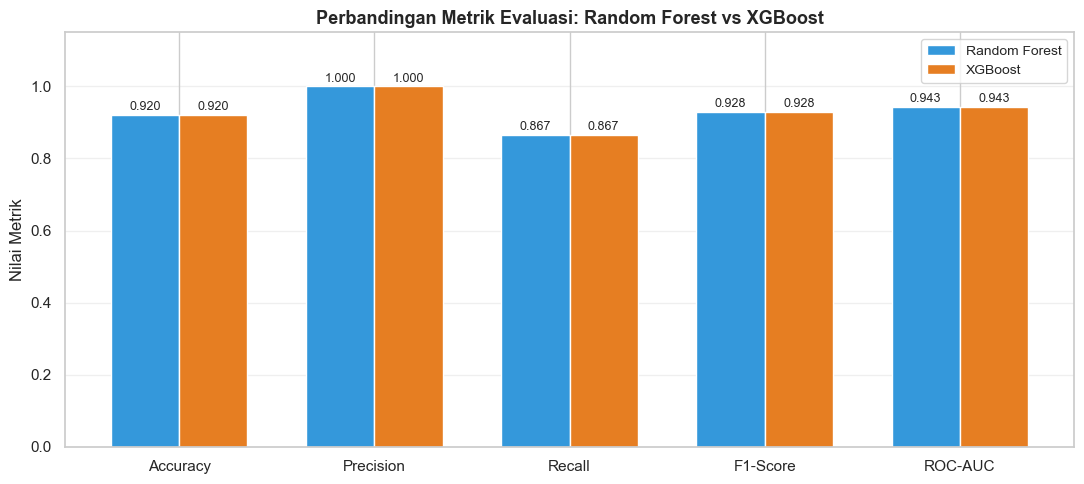

 Visualisasi perbandingan metrik ditampilkan


In [24]:
# ── Visualisasi Perbandingan Metrik ───────────────────────────────────────────
# Bar chart digunakan untuk membandingkan nilai metrik evaluasi
# antara Random Forest (biru) dan XGBoost (oranye) secara berdampingan
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
rf_vals  = [metrics['Random Forest'][m] for m in metric_names]
xgb_vals = [metrics['XGBoost'][m] for m in metric_names]

x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color='#e67e22', edgecolor='white')

# Tambahkan label nilai di atas setiap bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Metrik Evaluasi: Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_metrik_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi perbandingan metrik ditampilkan")


### 5.3 Confusion Matrix

Confusion matrix menunjukkan detail prediksi benar dan salah untuk setiap kelas.


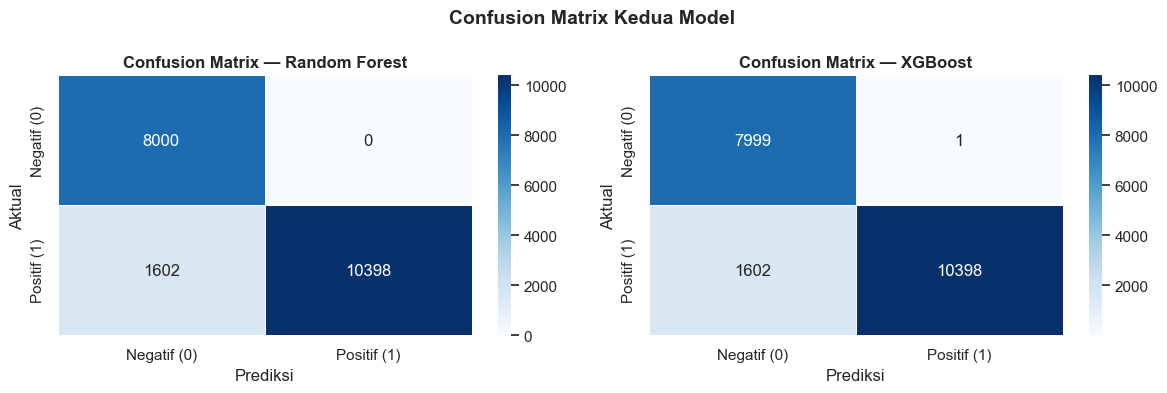

 Confusion matrix ditampilkan


In [25]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
# Confusion matrix terdiri dari 4 sel:
#   TN (True Negative)  : prediksi Tidak Diabetes, aktual Tidak Diabetes ✅
#   FP (False Positive) : prediksi Diabetes, aktual Tidak Diabetes ❌
#   FN (False Negative) : prediksi Tidak Diabetes, aktual Diabetes ❌
#   TP (True Positive)  : prediksi Diabetes, aktual Diabetes ✅
# Semakin besar nilai diagonal (TN dan TP), semakin baik model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Negatif (0)', 'Positif (1)'],
        yticklabels=['Negatif (0)', 'Positif (1)'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix Kedua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix ditampilkan")


### 5.4 ROC Curve

ROC Curve menunjukkan kemampuan model membedakan kelas positif dan negatif pada berbagai threshold.


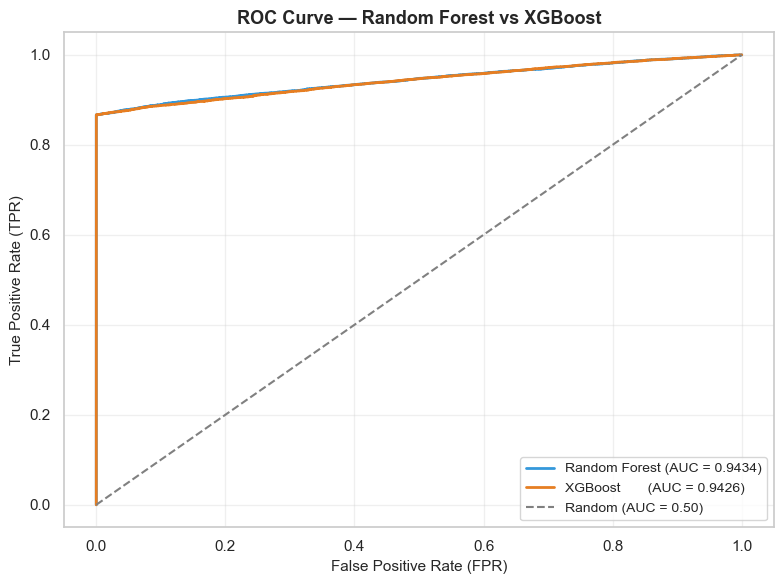

 ROC Curve ditampilkan


In [26]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
# ROC (Receiver Operating Characteristic) Curve menggambarkan trade-off antara:
#   - TPR (True Positive Rate / Recall) : sumbu Y
#   - FPR (False Positive Rate)         : sumbu X
# AUC (Area Under Curve): semakin mendekati 1.0, semakin baik model
# Garis diagonal putus-putus = model random (AUC=0.5)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_rf,  tpr_rf,  color='#3498db', lw=2,
        label=f'Random Forest (AUC = {metrics["Random Forest"]["ROC-AUC"]:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='#e67e22', lw=2,
        label=f'XGBoost       (AUC = {metrics["XGBoost"]["ROC-AUC"]:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random (AUC = 0.50)')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC Curve — Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(" ROC Curve ditampilkan")


### 5.5 Feature Importance

Menampilkan kontribusi setiap fitur terhadap keputusan model.


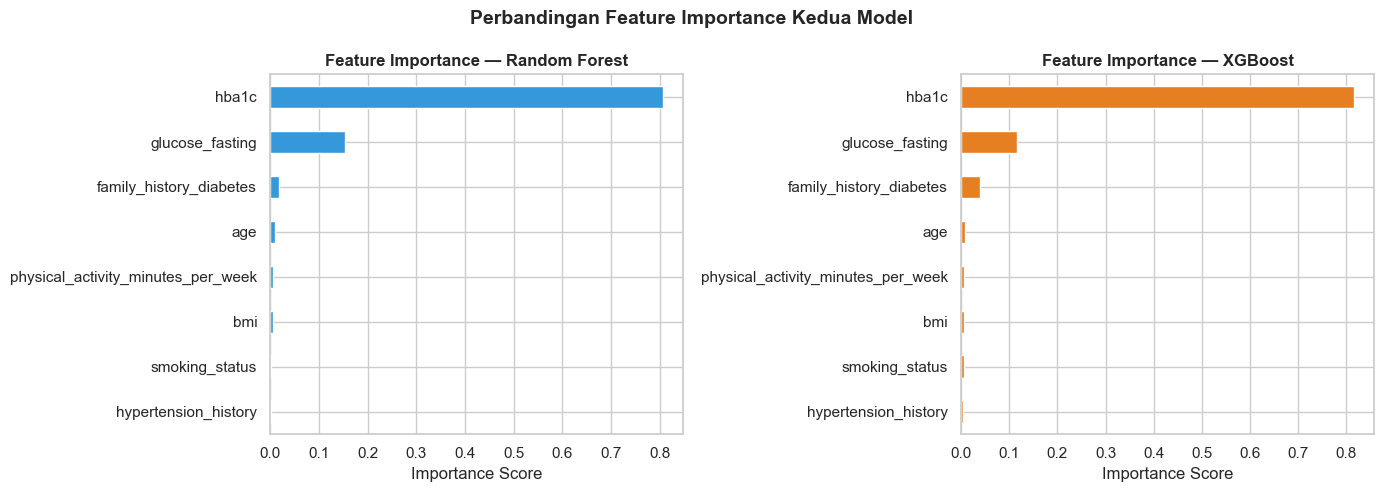


 Fitur terpenting (Random Forest) : hba1c
 Fitur terpenting (XGBoost)       : hba1c


In [27]:
# ── Feature Importance ────────────────────────────────────────────────────────
# feature_importances_ menunjukkan seberapa penting setiap fitur bagi model
# Nilai lebih tinggi = fitur lebih berpengaruh pada keputusan prediksi
# Ini memvalidasi bahwa 8 fitur yang dipilih memang relevan
rf_importance  = pd.Series(rf_model.feature_importances_,  index=X.columns).sort_values(ascending=True)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
rf_importance.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Feature Importance — Random Forest', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost
xgb_importance.plot(kind='barh', ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_title('Feature Importance — XGBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Perbandingan Feature Importance Kedua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n Fitur terpenting (Random Forest) : {rf_importance.idxmax()}")
print(f" Fitur terpenting (XGBoost)       : {xgb_importance.idxmax()}")


### 5.6 Cross-Validation (5-Fold)

Cross-validation membagi data menjadi 5 bagian (fold), melatih model 5 kali secara bergantian, dan mengambil rata-rata akurasi. Ini memberikan evaluasi yang lebih robust dibanding satu kali split saja.


In [28]:
# ── Stratified K-Fold Cross Validation ───────────────────────────────────────
# StratifiedKFold: setiap fold memiliki proporsi kelas yang sama
# n_splits=5: data dibagi menjadi 5 bagian
# cross_val_score: melatih dan mengevaluasi model sebanyak n_splits kali
# scoring='accuracy': metrik yang digunakan untuk evaluasi setiap fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("⏳ Menjalankan Cross-Validation 5-Fold...")
rf_cv_scores  = cross_val_score(rf_model,  X_scaled, y, cv=skf, scoring='accuracy', n_jobs=-1)
xgb_cv_scores = cross_val_score(xgb_model, X_scaled, y, cv=skf, scoring='accuracy', n_jobs=-1)

print("\n Hasil Cross-Validation:")
print(f"   Random Forest : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"   XGBoost       : {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")
print("\n   Detail per fold:")
for i, (rf_s, xgb_s) in enumerate(zip(rf_cv_scores, xgb_cv_scores), 1):
    print(f"   Fold {i} → RF: {rf_s:.4f} | XGB: {xgb_s:.4f}")


⏳ Menjalankan Cross-Validation 5-Fold...

 Hasil Cross-Validation:
   Random Forest : 0.9211 ± 0.0011
   XGBoost       : 0.9210 ± 0.0011

   Detail per fold:
   Fold 1 → RF: 0.9223 | XGB: 0.9223
   Fold 2 → RF: 0.9224 | XGB: 0.9224
   Fold 3 → RF: 0.9202 | XGB: 0.9201
   Fold 4 → RF: 0.9195 | XGB: 0.9194
   Fold 5 → RF: 0.9211 | XGB: 0.9211


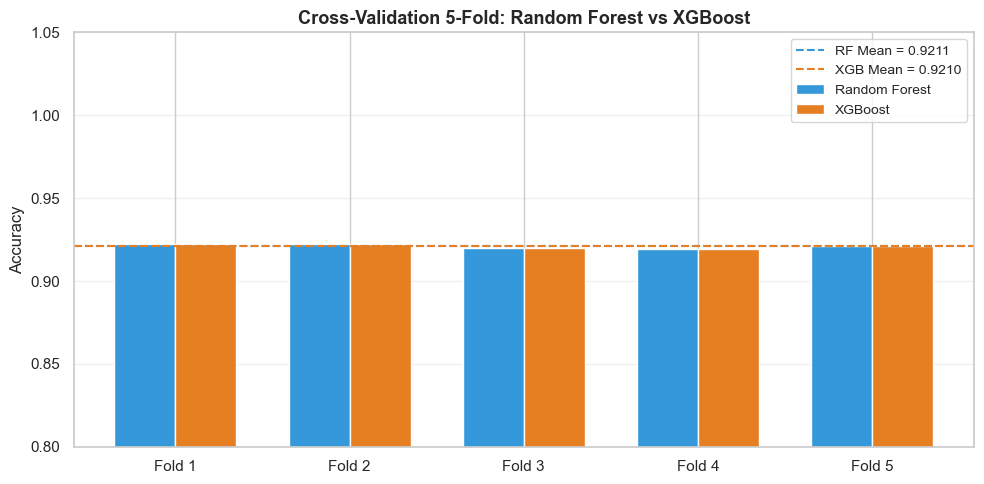

In [29]:
# ── Visualisasi Cross-Validation ──────────────────────────────────────────────
# Setiap bar menunjukkan akurasi pada 1 fold
# Garis putus-putus menunjukkan rata-rata akurasi dari semua fold
# Jika semua bar konsisten tinggi → model stabil dan generalizable
fig, ax = plt.subplots(figsize=(10, 5))
folds = [f'Fold {i+1}' for i in range(5)]
x     = np.arange(5)
width = 0.35

ax.bar(x - width/2, rf_cv_scores,  width, label='Random Forest', color='#3498db', edgecolor='white')
ax.bar(x + width/2, xgb_cv_scores, width, label='XGBoost',       color='#e67e22', edgecolor='white')
ax.axhline(rf_cv_scores.mean(),  color='#3498db', linestyle='--', linewidth=1.5,
           label=f'RF Mean = {rf_cv_scores.mean():.4f}')
ax.axhline(xgb_cv_scores.mean(), color='#e67e22', linestyle='--', linewidth=1.5,
           label=f'XGB Mean = {xgb_cv_scores.mean():.4f}')

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylim(0.8, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation 5-Fold: Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.7 Deteksi Overfitting dan Underfitting

Overfitting terjadi ketika model sangat baik pada data latih tapi buruk pada data uji (gap besar antara train & test accuracy). Underfitting terjadi ketika akurasi keduanya rendah.

**Interpretasi:**
- **Normal** : Train accuracy dan Test accuracy sama-sama tinggi dan berdekatan
- **Overfitting** : Train accuracy jauh lebih tinggi dari Test accuracy (gap > 5%)
- **Underfitting** : Keduanya rendah (< 70%)


In [30]:
# ── Deteksi Overfitting / Underfitting ───────────────────────────────────────
# Caranya: bandingkan akurasi model pada DATA TRAIN vs DATA TEST
# Jika akurasi TRAIN jauh lebih tinggi dari TEST → model overfitting
# (model hafal data latih, tapi tidak bisa generalisasi ke data baru)
# Jika keduanya rendah → underfitting (model terlalu sederhana)
rf_train_acc  = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc   = accuracy_score(y_test,  y_pred_rf)
xgb_train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
xgb_test_acc  = accuracy_score(y_test,  y_pred_xgb)

print(" Perbandingan Akurasi Train vs Test:")
print("-" * 50)
print(f"{'Model':<20} {'Train Acc':>12} {'Test Acc':>12} {'Gap':>8}")
print("-" * 50)
print(f"{'Random Forest':<20} {rf_train_acc:>12.4f} {rf_test_acc:>12.4f} {abs(rf_train_acc - rf_test_acc):>8.4f}")
print(f"{'XGBoost':<20} {xgb_train_acc:>12.4f} {xgb_test_acc:>12.4f} {abs(xgb_train_acc - xgb_test_acc):>8.4f}")
print("-" * 50)

print("\n Interpretasi Overfitting / Underfitting:")
for name, train_acc, test_acc in [
    ('Random Forest', rf_train_acc, rf_test_acc),
    ('XGBoost',       xgb_train_acc, xgb_test_acc)
]:
    gap = train_acc - test_acc
    if test_acc < 0.70:
        status = "  UNDERFITTING — Akurasi terlalu rendah, model terlalu sederhana"
    elif gap > 0.05:
        status = "  OVERFITTING   — Gap train-test terlalu besar, model hafal data latih"
    else:
        status = " NORMAL         — Model mampu generalisasi dengan baik"
    print(f"   {name}: {status}")


 Perbandingan Akurasi Train vs Test:
--------------------------------------------------
Model                   Train Acc     Test Acc      Gap
--------------------------------------------------
Random Forest              0.9214       0.9199   0.0015
XGBoost                    0.9215       0.9198   0.0017
--------------------------------------------------

 Interpretasi Overfitting / Underfitting:
   Random Forest:  NORMAL         — Model mampu generalisasi dengan baik
   XGBoost:  NORMAL         — Model mampu generalisasi dengan baik


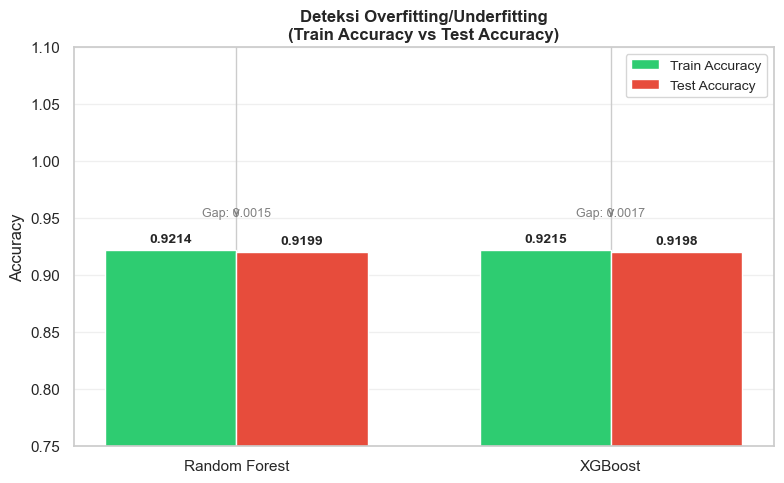

 Visualisasi overfitting/underfitting ditampilkan


In [31]:
# ── Visualisasi Overfitting/Underfitting ──────────────────────────────────────
# Grafik grouped bar chart membandingkan akurasi Train vs Test tiap model
# Semakin kecil selisih antara bar Train dan Test, semakin sehat model
labels  = ['Random Forest', 'XGBoost']
train_accs = [rf_train_acc, xgb_train_acc]
test_accs  = [rf_test_acc,  xgb_test_acc]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',  color='#e74c3c', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0.75, 1.10)
ax.set_ylabel('Accuracy')
ax.set_title('Deteksi Overfitting/Underfitting\n(Train Accuracy vs Test Accuracy)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Tambahkan anotasi GAP
for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
    ax.annotate(f'Gap: {abs(tr-te):.4f}',
                xy=(i, max(tr, te) + 0.03),
                ha='center', fontsize=9, color='gray',
                arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('plot_overfit_underfit.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi overfitting/underfitting ditampilkan")


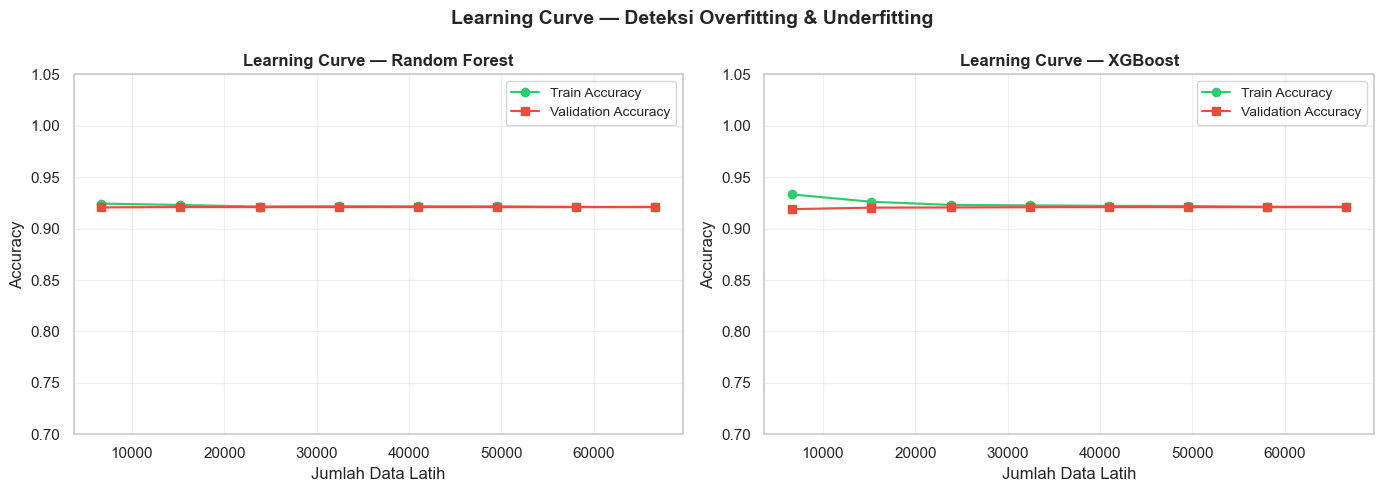

 Learning curve ditampilkan


In [32]:
# ── Learning Curve (Overfitting Check Lanjutan) ───────────────────────────────
# Learning curve menunjukkan bagaimana akurasi model berubah
# seiring bertambahnya jumlah data latih
# Interpretasi:
#   - Jika garis train dan validation berdekatan di akhir → NORMAL
#   - Jika train tinggi tapi validation rendah dan tidak bertemu → OVERFITTING
#   - Jika keduanya rendah dan datar → UNDERFITTING
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [('Random Forest', rf_model), ('XGBoost', xgb_model)]):
    tr_sizes, tr_scores, val_scores = learning_curve(
        model, X_scaled, y,
        train_sizes=train_sizes,
        cv=3, scoring='accuracy', n_jobs=-1
    )

    tr_mean  = tr_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    tr_std   = tr_scores.std(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(tr_sizes, tr_mean,  'o-', color='#2ecc71', label='Train Accuracy')
    ax.plot(tr_sizes, val_mean, 's-', color='#e74c3c', label='Validation Accuracy')
    ax.fill_between(tr_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.1, color='#2ecc71')
    ax.fill_between(tr_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#e74c3c')

    ax.set_title(f'Learning Curve — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Jumlah Data Latih')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.7, 1.05)

plt.suptitle('Learning Curve — Deteksi Overfitting & Underfitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Learning curve ditampilkan")


### 5.8 Classification Report Lengkap


In [33]:
# ── Classification Report ─────────────────────────────────────────────────────
# classification_report menampilkan metrik per kelas:
#   - precision, recall, f1-score untuk kelas 0 (Negatif) dan kelas 1 (Positif)
#   - support: jumlah data aktual per kelas
#   - macro avg   : rata-rata sederhana semua kelas
#   - weighted avg: rata-rata berbobot berdasarkan jumlah data per kelas
print("Classification Report — Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Negatif (0)', 'Positif (1)']))

print("\n Classification Report — XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=['Negatif (0)', 'Positif (1)']))


Classification Report — Random Forest:
              precision    recall  f1-score   support

 Negatif (0)       0.83      1.00      0.91      8000
 Positif (1)       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000


 Classification Report — XGBoost:
              precision    recall  f1-score   support

 Negatif (0)       0.83      1.00      0.91      8000
 Positif (1)       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



---
##  FASE 6 — Deployment (Export Model)

Fase terakhir: menyimpan model, scaler, dan encoder ke file `.pkl` agar dapat diintegrasikan ke aplikasi web.


In [34]:
# ── Simpan Semua Artefak Model ────────────────────────────────────────────────
# joblib.dump() menyimpan objek Python ke file binary (.pkl)
# File .pkl ini yang nantinya di-load oleh backend FastAPI/Flask
# Tanpa menyimpan scaler dan encoder, prediksi di web tidak akan akurat!
import joblib

joblib.dump(rf_model,       'model_rf_8fitur.pkl')
print(" model_rf_8fitur.pkl berhasil disimpan")

joblib.dump(xgb_model,      'model_xgb_8fitur.pkl')
print(" model_xgb_8fitur.pkl berhasil disimpan")

joblib.dump(scaler,         'scaler_8fitur.pkl')
print(" scaler_8fitur.pkl berhasil disimpan")

joblib.dump(label_encoders, 'label_encoders_8fitur.pkl')
print(" label_encoders_8fitur.pkl berhasil disimpan")

joblib.dump(list(X.columns), 'feature_columns_8fitur.pkl')
print(" feature_columns_8fitur.pkl berhasil disimpan")


 model_rf_8fitur.pkl berhasil disimpan
 model_xgb_8fitur.pkl berhasil disimpan
 scaler_8fitur.pkl berhasil disimpan
 label_encoders_8fitur.pkl berhasil disimpan
 feature_columns_8fitur.pkl berhasil disimpan
